In [1]:
import time
from functools import partial
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# Set a random seed for reproducibility
key = jax.random.PRNGKey(42)

## Problem Overview: 1D Ordinary Differential Equation

We are using a Physics-Informed Neural Network (PINN) to solve the following first-order ordinary differential equation:

$$\frac{d^2y}{dx^2} = 6x$$

### Domain and Conditions
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Exact Solution
The analytical solution for this specific problem is:
$$y(x) = {x^3}$$

In [2]:
def exact_solution(x):
    return (x**3)

def plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch):
    test_error = jnp.mean(jnp.abs(y_test_batch - y_exact_batch) / y_exact_batch.std())
    plt.figure(figsize=(8,3))
    plt.scatter(x_physics_batch[:,0], jnp.zeros_like(x_physics_batch)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
    plt.scatter(x_boundary, 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point (x=0)")
    plt.plot(x_test_batch[:,0], y_exact_batch[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x_test_batch[:,0], y_test_batch[:,0], label="PINN solution", color="tab:green")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step {i} | Relative L1 Error: {test_error:.2%}")
    plt.legend()
    plt.show()

In [3]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [4]:
key1, key2 = jax.random.split(key)
params_y1 = FCN.init_parameters(key1, [1, 32, 32, 1])  # represents y₁(x) = y(x)
params_y2 = FCN.init_parameters(key2, [1, 32, 32, 1])  # represents y₂(x) = y'(x)
all_params = (params_y1, params_y2)

In [5]:
def trapezoidal_integral(y_values, x_values):
    """Vectorized trapezoidal rule for JAX."""
    dx = x_values[1] - x_values[0]
    # Calculate trapezoid areas: (y_i + y_{i+1})/2 * dx
    mid_points = (y_values[:-1] + y_values[1:]) / 2.0
    # Cumulative sum to get the integral at each point
    integral = jnp.cumsum(mid_points * dx)
    # Prepend 0 so the integral at the first point (x=0) is 0
    return jnp.concatenate([jnp.array([0.0]), integral])

In [6]:
def PINN_loss_batch(all_params, x_physics_batch, network):
    params_y1, params_y2 = all_params
    x_vals = x_physics_batch.squeeze()

    y1_pred = jax.vmap(network.forward, in_axes=(None, 0))(params_y1, x_physics_batch).squeeze()
    y2_pred = jax.vmap(network.forward, in_axes=(None, 0))(params_y2, x_physics_batch).squeeze()

    y0  = 0.0   # y(0) = 0
    dy0 = 0.0   # y'(0) = 0

    # Method 3 on sub-ODE 1: y₁' = y₂  →  y₁(x) = y₁(0) + ∫₀ˣ y₂(s) ds
    integral_y2 = trapezoidal_integral(y2_pred, x_vals)
    residual_y1 = y1_pred - (y0 + integral_y2)

    # Method 3 on sub-ODE 2: y₂' = 6x  →  y₂(x) = y₂(0) + ∫₀ˣ 6s ds
    rhs_y2 = 6.0 * x_vals
    integral_rhs = trapezoidal_integral(rhs_y2, x_vals)
    residual_y2 = y2_pred - (dy0 + integral_rhs)

    return jnp.mean(residual_y1**2) + jnp.mean(residual_y2**2)

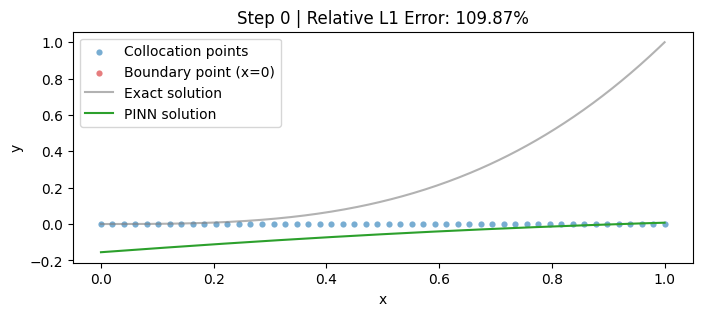

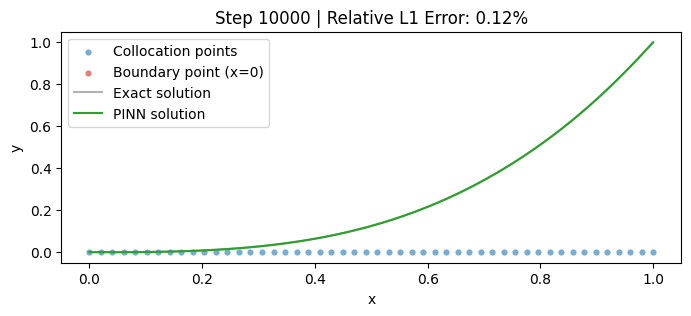

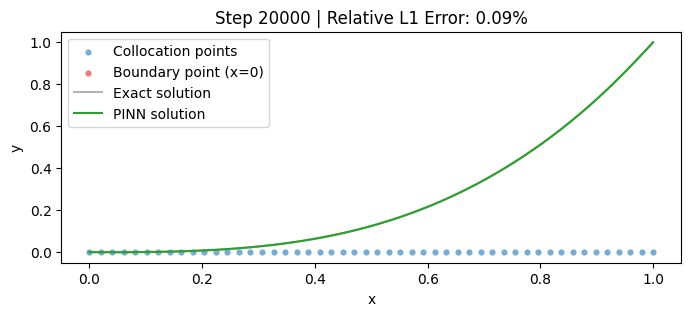

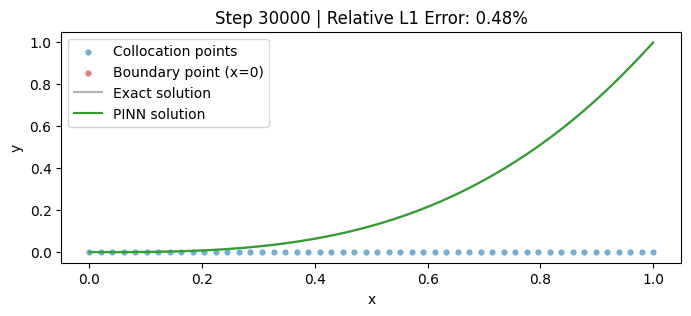

In [7]:
@partial(jax.jit, static_argnums=(1, 3))
def PINN_step(opt_state, optimiser, all_params, network, x_physics_batch):
    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        all_params, x_physics_batch, network)
    updates, opt_state = optimiser.update(grads, opt_state, all_params)
    all_params = optax.apply_updates(all_params, updates)
    return loss, opt_state, all_params

# Setup and Execution
x_boundary = jnp.array([0.0])
x_physics_batch = jnp.linspace(0, 1, 50).reshape(-1, 1)
x_test_batch = jnp.linspace(0, 1, 300).reshape(-1, 1)
y_exact_batch = jax.vmap(exact_solution)(x_test_batch)

network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(all_params)

for i in range(30001):
    loss, opt_state, all_params = PINN_step(
        opt_state, optimiser, all_params, network, x_physics_batch)
    if i % 10000 == 0:
        y_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(
            all_params[0], x_test_batch)   # use params_y1 = all_params[0]
        plot_result(i, x_physics_batch, None, x_test_batch, y_exact_batch, y_test_batch)

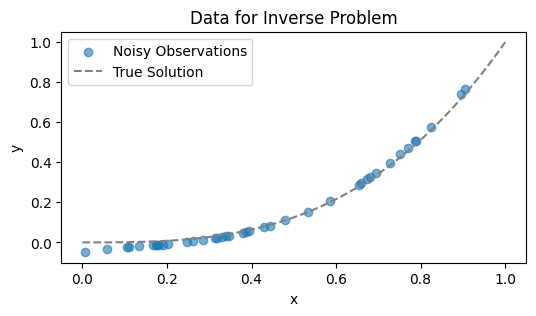

In [8]:
# 1. Define the updated exact solution for data generation
def exact_solution(x):
    return (x**3)

# 2. Generate noisy observational data
key, subkey = jax.random.split(key)
# Randomly sample 40 points in the domain [0, 1]
x_obs = (jax.random.uniform(subkey, (40, 1)))
# Generate true y values and add 5% Gaussian noise
y_obs = exact_solution(x_obs) + 0.02 * jax.random.normal(subkey, (40, 1))

# Visualize the data the PINN will learn from
plt.figure(figsize=(6, 3))
plt.scatter(x_obs, y_obs, label="Noisy Observations", color="tab:blue", alpha=0.6)
x_plot = jnp.linspace(0, 1, 100)
plt.plot(x_plot, exact_solution(x_plot), label="True Solution", color="grey", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Data for Inverse Problem")
plt.show()

Step 0 | Loss: 1.7591e-01 | Alpha Estimate: -0.0010
Step 2000 | Loss: 2.1749e-02 | Alpha Estimate: 1.5301
Step 4000 | Loss: 9.2191e-03 | Alpha Estimate: 3.1672
Step 6000 | Loss: 2.6270e-03 | Alpha Estimate: 4.6078
Step 8000 | Loss: 3.8279e-04 | Alpha Estimate: 5.6766
Step 10000 | Loss: 1.1722e-04 | Alpha Estimate: 6.1347
Step 12000 | Loss: 1.1190e-04 | Alpha Estimate: 6.1878
Step 14000 | Loss: 1.1109e-04 | Alpha Estimate: 6.1901


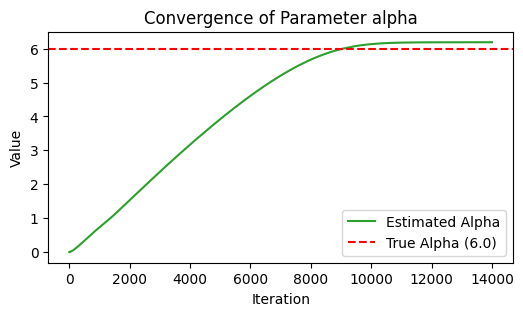

In [9]:
def PINN_inverse_loss_batch(params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    params_y1, params_y2, alpha = params_and_alpha
    x_vals = x_physics_batch.squeeze()
    y0, dy0 = 0.0, 0.0

    y1_pred = jax.vmap(network.forward, in_axes=(None,0))(params_y1, x_physics_batch).squeeze()
    y2_pred = jax.vmap(network.forward, in_axes=(None,0))(params_y2, x_physics_batch).squeeze()

    # Sub-ODE 1: y₁' = y₂
    residual_y1 = y1_pred - (y0 + trapezoidal_integral(y2_pred, x_vals))

    # Sub-ODE 2: y₂' = αx
    residual_y2 = y2_pred - (dy0 + trapezoidal_integral(alpha * x_vals, x_vals))

    loss_physics = jnp.mean(residual_y1**2) + jnp.mean(residual_y2**2)

    # Data loss on y (= y₁)
    y1_obs_pred = jax.vmap(network.forward, in_axes=(None,0))(params_y1, x_obs).squeeze()
    loss_data = jnp.mean((y1_obs_pred - y_obs.squeeze())**2)

    return loss_physics + loss_data

# 3. Define JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 6))
def inverse_step(opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    """Updates PINN parameters and the unknown alpha using the optax optimiser"""

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=0)(
        params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    # apply parameter update
    updates, opt_state = optimiser.update(grads, opt_state, params_and_alpha)
    params_and_alpha = optax.apply_updates(params_and_alpha, updates)

    return loss, opt_state, params_and_alpha

# 4. Initialize and Run Training
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
alpha_init = jnp.array(0.0) # Initial guess
params_and_alpha = (params_y1, params_y2, jnp.array(0.0))

optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params_and_alpha)

alphas = []
for i in range(14001):
    loss, opt_state, params_and_alpha = inverse_step(
        opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    current_alpha = params_and_alpha[2] # Corrected index to get alpha
    alphas.append(current_alpha)

    if i % 2000 == 0:
        # In Method 3, the NN represents the solution directly
        y_test_pred = jax.vmap(network.forward, in_axes=(None, 0))(
            params_and_alpha[0], x_test_batch).squeeze()
        print(f"Step {i} | Loss: {loss:.4e} | Alpha Estimate: {current_alpha:.4f}")

# Plot convergence
plt.figure(figsize=(6, 3))
plt.plot(alphas, label="Estimated Alpha", color="tab:green")
plt.axhline(y=6.0, color="red", linestyle="--", label="True Alpha (6.0)") # Corrected true alpha
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.title("Convergence of Parameter alpha")
plt.show()